# Phase 2: Transformer Scaling Study
## SVG Scaling Laws — CS-GY 6923

**Steps:**
1. Mount Drive & clone/pull repo
2. Install dependencies
3. Configure paths
4. Print model parameter counts
5. Run LR sweep (Tiny, 2000 steps × 7 LRs)
6. Update best LR in config
7. Train each of the 5 models individually
8. Fit scaling law & generate all plots

---
## Cell 0: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/svg-scaling-laws'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project dir: /content/drive/MyDrive/svg-scaling-laws


---
## Cell 1: Clone / Pull Repository

In [ ]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/svg-scaling-laws'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
print(f'Working directory: {os.getcwd()}')

Repo already exists, pulling latest ...
Already up to date.
/content/svg-scaling-laws
Working directory: /content/svg-scaling-laws


---
## Cell 2: Install Dependencies

In [ ]:
!pip install -q -r requirements.txt
print('Dependencies installed.')

Dependencies installed.


---
## Cell 3: Configure Output Paths
Symlink `outputs/` → Drive so checkpoints/logs persist across sessions.

In [ ]:
import os, sys

REPO_DIR     = '/content/svg-scaling-laws'
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.islink(LOCAL_OUTPUTS):
    os.unlink(LOCAL_OUTPUTS)
elif os.path.exists(LOCAL_OUTPUTS):
    import shutil
    shutil.rmtree(LOCAL_OUTPUTS)

os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
print(f'Symlink: {LOCAL_OUTPUTS} -> {DRIVE_OUTPUTS}')

# Ensure subdirs exist
for d in ['logs', 'checkpoints', 'plots', 'data/binary']:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, d), exist_ok=True)

# Add repo to Python path
sys.path.insert(0, REPO_DIR)
print('Path configured.')

Symlink: /content/svg-scaling-laws/outputs -> /content/drive/MyDrive/svg-scaling-laws/outputs
Path configured.


---
## Cell 4: Verify Binary Data & Print Model Parameter Counts
Confirm Phase 1 outputs are on Drive, then print exact param counts for all 5 models.

In [ ]:
import json, os
import numpy as np

# ---- Verify binary data ----
binary_dir = 'outputs/data/binary'
print('Binary files:')
for split in ['train', 'val', 'test']:
    p = os.path.join(binary_dir, f'{split}.bin')
    if os.path.exists(p):
        arr = np.memmap(p, dtype=np.uint16, mode='r')
        print(f'  {split}.bin: {len(arr):,} tokens  ({os.path.getsize(p)/1e6:.1f} MB)')
    else:
        print(f'  {split}.bin: MISSING — run Phase 1 first!')

split_info_path = os.path.join(binary_dir, 'split_info.json')
if os.path.exists(split_info_path):
    with open(split_info_path) as f:
        si = json.load(f)
    print(f'\nSplit info: {json.dumps(si, indent=2)}')

# ---- Model parameter counts ----
from src.model import MODEL_CONFIGS, TransformerLM, print_model_summary
print('\n' + '='*60)
print('MODEL PARAMETER COUNTS')
print('='*60)
print_model_summary()

Binary files:
  train.bin: 130,404,653 tokens  (260.8 MB)
  val.bin: 1,326,073 tokens  (2.7 MB)
  test.bin: 1,341,361 tokens  (2.7 MB)

Split info: {
  "train_svgs": 1147128,
  "val_svgs": 11705,
  "test_svgs": 11705,
  "train_tokens": 130404653,
  "val_tokens": 1326073,
  "test_tokens": 1341361,
  "total_tokens": 133072087,
  "max_token_length": 1024,
  "n_filtered_too_long": 87,
  "vocab_size": 4096,
  "dtype": "uint16",
  "bos_id": 1,
  "eos_id": 2,
  "seed": 42
}

MODEL PARAMETER COUNTS

Model       d_model  n_layers  n_heads   d_ff   Non-emb params
-----------------------------------------------------------------
tiny            128         4        4    512          793,344
small           192         6        6    768        2,669,568
medium          384         6        6   1536       10,647,552
large           512        10        8   2048       31,524,864
xl              768        12       12   3072       85,056,000



---
## Cell 5: LR Sweep — Tiny Model
Trains Tiny at 7 learning rates (2000 steps each). Takes ~15-20 min on A100.

After this cell completes, read the best LR from the output and update Cell 6.

In [ ]:
!python scripts/06_lr_sweep.py --training_config configs/training_config.yaml

Device: cuda
LR sweep: 7 values × 2000 steps each
LRs: [3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]

[1/7] lr=3.0e-05 ... val=6.1804  (119s)
[2/7] lr=1.0e-04 ... val=5.1360  (72s)
[3/7] lr=3.0e-04 ... val=4.1948  (72s)
[4/7] lr=1.0e-03 ... val=6.5137  (72s)
[5/7] lr=3.0e-03 ... val=7.8532  (72s)
[6/7] lr=1.0e-02 ... DIVERGED  (72s)
[7/7] lr=3.0e-02 ... DIVERGED  (72s)

Best LR: 3.0e-04  →  val_loss=4.1948
Set `learning_rate: 3.0e-04` in configs/training_config.yaml before running script 05.

Results saved to /content/svg-scaling-laws/outputs/logs/lr_sweep_sp.json
LR sweep plot saved to /content/svg-scaling-laws/outputs/plots/lr_sweep_sp.png

          LR     Val loss   Diverged
--------------------------------------
     3.0e-05       6.1804      False  
     1.0e-04       5.1360      False  
     3.0e-04       4.1948      False *
     1.0e-03       6.5137      False  
     3.0e-03       7.8532      False  
     1.0e-02          nan       True  
     3.0e-02          nan       Tru

---
## Cell 6: Display LR Sweep Results & Set Best LR

Best LR: 3.0e-04  →  val_loss=4.1948

All runs:
          LR     Val loss   Diverged
--------------------------------------
     3.0e-05       6.1804      False  
     1.0e-04       5.1360      False  
     3.0e-04       4.1948      False *
     1.0e-03       6.5137      False  
     3.0e-03       7.8532      False  
     1.0e-02          nan       True  
     3.0e-02          nan       True  


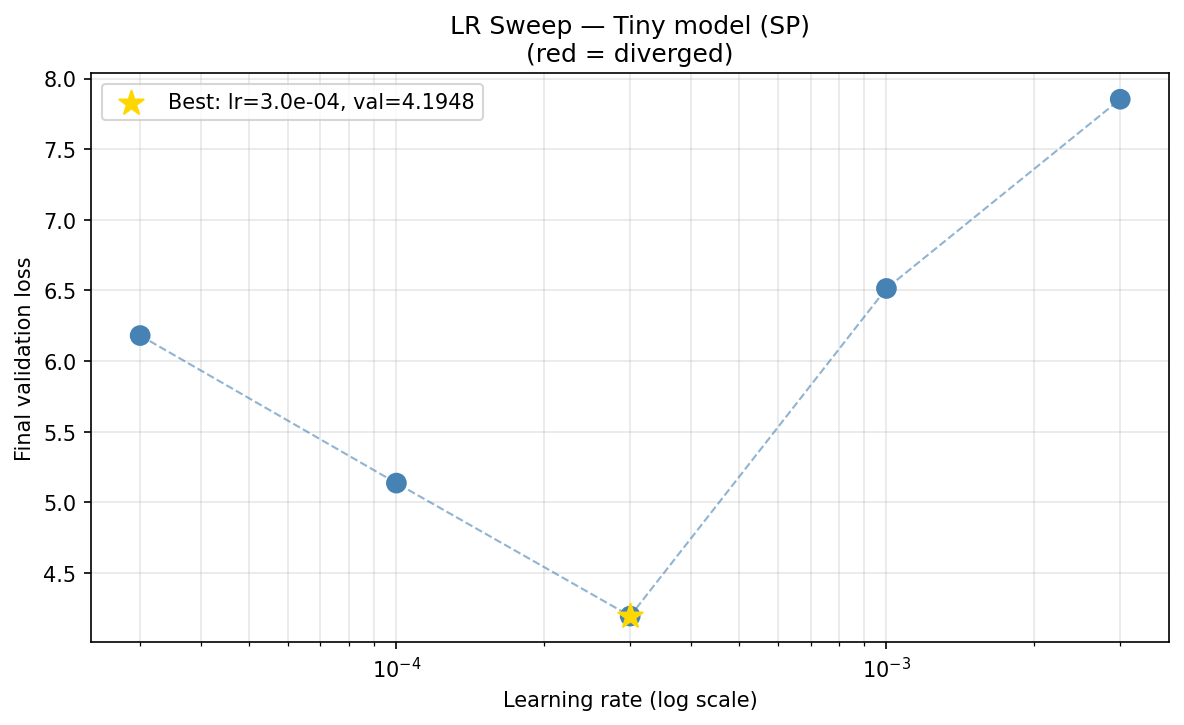


>>> Set learning_rate: 3.0e-04 in configs/training_config.yaml before training


In [ ]:
import json
from IPython.display import Image, display

with open('outputs/logs/lr_sweep_sp.json') as f:
    sweep = json.load(f)

print(f"Best LR: {sweep['best_lr']:.1e}  →  val_loss={sweep['best_val_loss']:.4f}")
print(f"\nAll runs:")
print(f"{'LR':>12} {'Val loss':>12} {'Diverged':>10}")
print("-" * 38)
for r in sorted(sweep['runs'], key=lambda x: x['lr']):
    marker = '*' if r['lr'] == sweep['best_lr'] else ' '
    print(f"{r['lr']:>12.1e} {r['val_loss']:>12.4f} {str(r['diverged']):>10} {marker}")

display(Image('outputs/plots/lr_sweep_sp.png'))

print(f"\n>>> Set learning_rate: {sweep['best_lr']:.1e} in configs/training_config.yaml before training")

In [ ]:
# Auto-update training_config.yaml with the best LR found above
import yaml, json

with open('outputs/logs/lr_sweep_sp.json') as f:
    sweep = json.load(f)

best_lr = sweep['best_lr']

with open('configs/training_config.yaml') as f:
    tcfg = yaml.safe_load(f)

tcfg['learning_rate'] = best_lr

with open('configs/training_config.yaml', 'w') as f:
    yaml.dump(tcfg, f, default_flow_style=False, allow_unicode=True)

print(f'configs/training_config.yaml updated: learning_rate = {best_lr:.1e}')

configs/training_config.yaml updated: learning_rate = 3.0e-04


---
## Cell 7: Train — Tiny
~10 min on A100. Resumes from last checkpoint if Colab disconnected.

In [ ]:
!python scripts/05_train_model.py --model_name tiny --resume

Device: cuda
Compiling model with torch.compile ...
Model: tiny  |  Non-emb params: 793,344
Train tokens: 130,404,653  |  steps/epoch: 1,989
No checkpoint found — starting from scratch.

Training: TINY
  Non-emb params:  793,344
  Peak LR:         3.00e-04
  Batch size:      64 seqs × 1024 tokens = 65,536 tok/step
  Grad accum:      1  (effective batch: 64 seqs)
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/tiny/
  Drive ckpts:     /content/svg-scaling-laws/outputs/checkpoints/tiny/
  Log:             /content/svg-scaling-laws/outputs/logs/training_tiny.csv

Training tiny for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3422 | val 8.3404 * | lr 0.00e+00 | tok 0.1M | t 0.1min | mem 590MB
step     50 | train 7.9122 | lr 7.50e-05 | tok 3.3M | t 0.1min
step    100 | train 7.0801 | lr 1.50e-04 | tok 6.6M | t 0.1min
step    150 | train 6.5359 | lr 2.25e-04 | tok 9.9M | t 0.2min
step    200 | train 6.3096 | val 6.3112 * | lr 3.00e-04 

In [ ]:
import json
with open('outputs/logs/result_tiny.json') as f:
    r = json.load(f)
print(f"Tiny complete.  Val loss: {r['best_val_loss']:.4f}.  "
      f"Time: {r['wall_time_min']:.1f} min.  Params: {r['n_params']:,}")

Tiny complete.  Val loss: 4.3178.  Time: 1.5 min.  Params: 793,344


---
## Cell 8: Train — Small
~15 min on A100.

In [ ]:
!python scripts/05_train_model.py --model_name small --resume

Device: cuda
Compiling model with torch.compile ...
Model: small  |  Non-emb params: 2,669,568
Train tokens: 130,404,653  |  steps/epoch: 1,989
No checkpoint found — starting from scratch.

Training: SMALL
  Non-emb params:  2,669,568
  Peak LR:         3.00e-04
  Batch size:      64 seqs × 1024 tokens = 65,536 tok/step
  Grad accum:      1  (effective batch: 64 seqs)
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/small/
  Drive ckpts:     /content/svg-scaling-laws/outputs/checkpoints/small/
  Log:             /content/svg-scaling-laws/outputs/logs/training_small.csv

Training small for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3552 | val 8.3542 * | lr 0.00e+00 | tok 0.1M | t 0.5min | mem 627MB
step     50 | train 7.6896 | lr 7.50e-05 | tok 3.3M | t 0.6min
step    100 | train 6.7310 | lr 1.50e-04 | tok 6.6M | t 0.6min
step    150 | train 6.3497 | lr 2.25e-04 | tok 9.9M | t 0.7min
step    200 | train 6.1540 | val 6.1573 * | lr

In [ ]:
import json
with open('outputs/logs/result_small.json') as f:
    r = json.load(f)
print(f"Small complete.  Val loss: {r['best_val_loss']:.4f}.  "
      f"Time: {r['wall_time_min']:.1f} min.  Params: {r['n_params']:,}")

Small complete.  Val loss: 4.0401.  Time: 3.4 min.  Params: 2,669,568


---
## Cell 9: Train — Medium
~30 min on A100.

In [ ]:
!python scripts/05_train_model.py --model_name medium --resume

Device: cuda
Compiling model with torch.compile ...
Model: medium  |  Non-emb params: 10,647,552
Train tokens: 130,404,653  |  steps/epoch: 1,989
No checkpoint found — starting from scratch.

Training: MEDIUM
  Non-emb params:  10,647,552
  Peak LR:         3.00e-04
  Batch size:      64 seqs × 1024 tokens = 65,536 tok/step
  Grad accum:      1  (effective batch: 64 seqs)
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/medium/
  Drive ckpts:     /content/svg-scaling-laws/outputs/checkpoints/medium/
  Log:             /content/svg-scaling-laws/outputs/logs/training_medium.csv

Training medium for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3902 | val 8.3890 * | lr 0.00e+00 | tok 0.1M | t 0.5min | mem 735MB
step     50 | train 7.1346 | lr 7.50e-05 | tok 3.3M | t 0.6min
step    100 | train 6.3537 | lr 1.50e-04 | tok 6.6M | t 0.7min
step    150 | train 6.1290 | lr 2.25e-04 | tok 9.9M | t 0.8min
step    200 | train 5.9655 | val 5.960

In [ ]:
import json
with open('outputs/logs/result_medium.json') as f:
    r = json.load(f)
print(f"Medium complete.  Val loss: {r['best_val_loss']:.4f}.  "
      f"Time: {r['wall_time_min']:.1f} min.  Params: {r['n_params']:,}")

Medium complete.  Val loss: 3.4757.  Time: 4.6 min.  Params: 10,647,552


---
## Cell 10: Train — Large
~60 min on A100.

In [ ]:
!python scripts/05_train_model.py --model_name large --resume

Device: cuda
Compiling model with torch.compile ...
Model: large  |  Non-emb params: 31,524,864
Train tokens: 130,404,653  |  steps/epoch: 1,989
No checkpoint found — starting from scratch.

Training: LARGE
  Non-emb params:  31,524,864
  Peak LR:         3.00e-04
  Batch size:      64 seqs × 1024 tokens = 65,536 tok/step
  Grad accum:      1  (effective batch: 64 seqs)
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/large/
  Drive ckpts:     /content/svg-scaling-laws/outputs/checkpoints/large/
  Log:             /content/svg-scaling-laws/outputs/logs/training_large.csv

Training large for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.4158 | val 8.4127 * | lr 0.00e+00 | tok 0.1M | t 0.8min | mem 1014MB
step     50 | train 6.8682 | lr 7.50e-05 | tok 3.3M | t 1.1min
step    100 | train 6.2595 | lr 1.50e-04 | tok 6.6M | t 1.3min
step    150 | train 6.0368 | lr 2.25e-04 | tok 9.9M | t 1.5min
step    200 | train 5.5772 | val 5.5284 * |

In [ ]:
import json
with open('outputs/logs/result_large.json') as f:
    r = json.load(f)
print(f"Large complete.  Val loss: {r['best_val_loss']:.4f}.  "
      f"Time: {r['wall_time_min']:.1f} min.  Params: {r['n_params']:,}")

Large complete.  Val loss: 3.2885.  Time: 10.3 min.  Params: 31,524,864


---
## Cell 11: Train — XL
~2-3 hours on A100. Save checkpoint to Drive frequently (every 500 steps).

In [ ]:
!python scripts/05_train_model.py --model_name xl --grad_accum 2 --resume

Device: cuda
Compiling model with torch.compile ...
Model: xl  |  Non-emb params: 85,056,000
Train tokens: 130,404,653  |  steps/epoch: 1,989
No checkpoint found — starting from scratch.

Training: XL
  Non-emb params:  85,056,000
  Peak LR:         3.00e-04
  Batch size:      32 seqs/step × 2 accum = 64 seqs effective
  Tokens/step:     65,536  (seq_len=1024)
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/xl/
  Drive ckpts:     /content/svg-scaling-laws/outputs/checkpoints/xl/
  Log:             /content/svg-scaling-laws/outputs/logs/training_xl.csv

Training xl for 1989 steps (bf16=True, grad_accum=2)
step      0 | train 8.4741 | val 8.4671 * | lr 0.00e+00 | tok 0.1M | t 0.9min | mem 1418MB
step     50 | train 6.5613 | lr 7.50e-05 | tok 3.3M | t 1.5min
step    100 | train 6.2013 | lr 1.50e-04 | tok 6.6M | t 1.8min
step    150 | train 5.9528 | lr 2.25e-04 | tok 9.9M | t 2.2min
step    200 | train 5.3118 | val 5.2936 * | lr 3.00e-04 | tok 13.

In [ ]:
import json
with open('outputs/logs/result_xl.json') as f:
    r = json.load(f)
print(f"XL complete.  Val loss: {r['best_val_loss']:.4f}.  "
      f"Time: {r['wall_time_min']:.1f} min.  Params: {r['n_params']:,}")

XL complete.  Val loss: 3.1043.  Time: 24.9 min.  Params: 85,056,000


---
## Cell 12: Summary — All Models Trained

In [ ]:
import json, os

model_names = ['tiny', 'small', 'medium', 'large', 'xl']
print(f"{'Model':<10} {'Params':>12} {'Best val L':>12} {'Time (min)':>12}")
print("-" * 52)

all_done = True
for name in model_names:
    p = f'outputs/logs/result_{name}.json'
    if os.path.exists(p):
        with open(p) as f:
            r = json.load(f)
        print(f"{name:<10} {r['n_params']:>12,} {r['best_val_loss']:>12.4f} "
              f"{r.get('wall_time_min', '?'):>12}")
    else:
        print(f"{name:<10} {'NOT TRAINED':>38}")
        all_done = False

if all_done:
    print("\nAll 5 models trained. Ready to fit scaling law.")
else:
    print("\nSome models still need training. Run the corresponding cells above.")

Model            Params   Best val L   Time (min)
----------------------------------------------------
tiny            793,344       4.3178          1.5
small         2,669,568       4.0401          3.4
medium       10,647,552       3.4757          4.6
large        31,524,864       3.2885         10.3
xl           85,056,000       3.1043         24.9

All 5 models trained. Ready to fit scaling law.


---
## Cell 13: Fit Scaling Law & Generate All Plots

In [ ]:
!python scripts/11_plot_results.py


Loaded results for: ['tiny', 'small', 'medium', 'large', 'xl']
Loaded training logs for: ['tiny', 'small', 'medium', 'large', 'xl']

Fitting scaling law on 5 models: ['tiny', 'small', 'medium', 'large', 'xl']
  tiny      N=   793,344  L=4.3178
  small     N= 2,669,568  L=4.0401
  medium    N=10,647,552  L=3.4757
  large     N=31,524,864  L=3.2885
  xl        N=85,056,000  L=3.1043

Scaling law fit (SP)
  L = 15.7880 * N^(-0.1259) + 1.4966
  a     = 15.7880  ±  16.7565
  alpha = 0.1259  ±  0.1370
  c     = 1.4966  ±  2.3459
  R²    = 0.9842
  (Kaplan et al. NL: alpha ≈ 0.076)
Scaling law plot saved to /content/svg-scaling-laws/outputs/plots/scaling_law_sp.png

Extrapolation (10× XL ≈ 851M params):
  Predicted L = 2.6824  95% CI: [2.1544, 3.2104]
Training curves saved to /content/svg-scaling-laws/outputs/plots/training_curves.png
LR sweep plot saved to /content/svg-scaling-laws/outputs/plots/lr_sweep_sp.png

Model          N params   Best val L     Tok seen   Wall (min)
----------------

---
## Cell 14: Display All Plots


--- Scaling Law (SP) ---


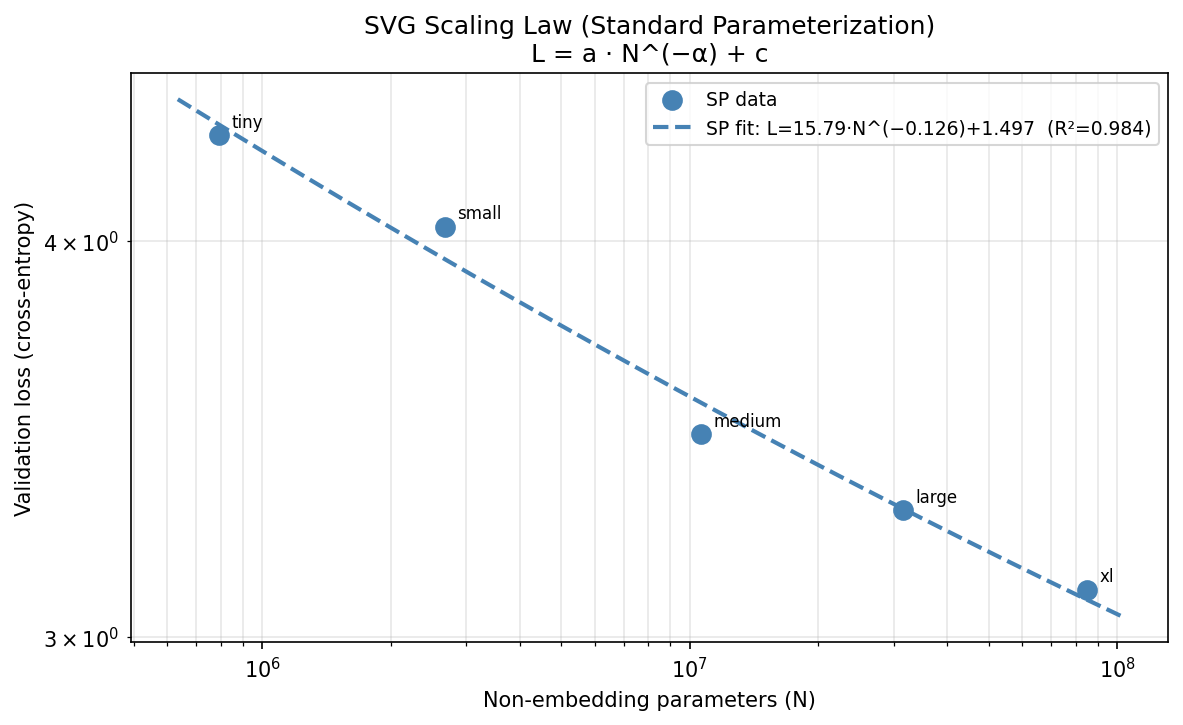


--- Training Curves ---


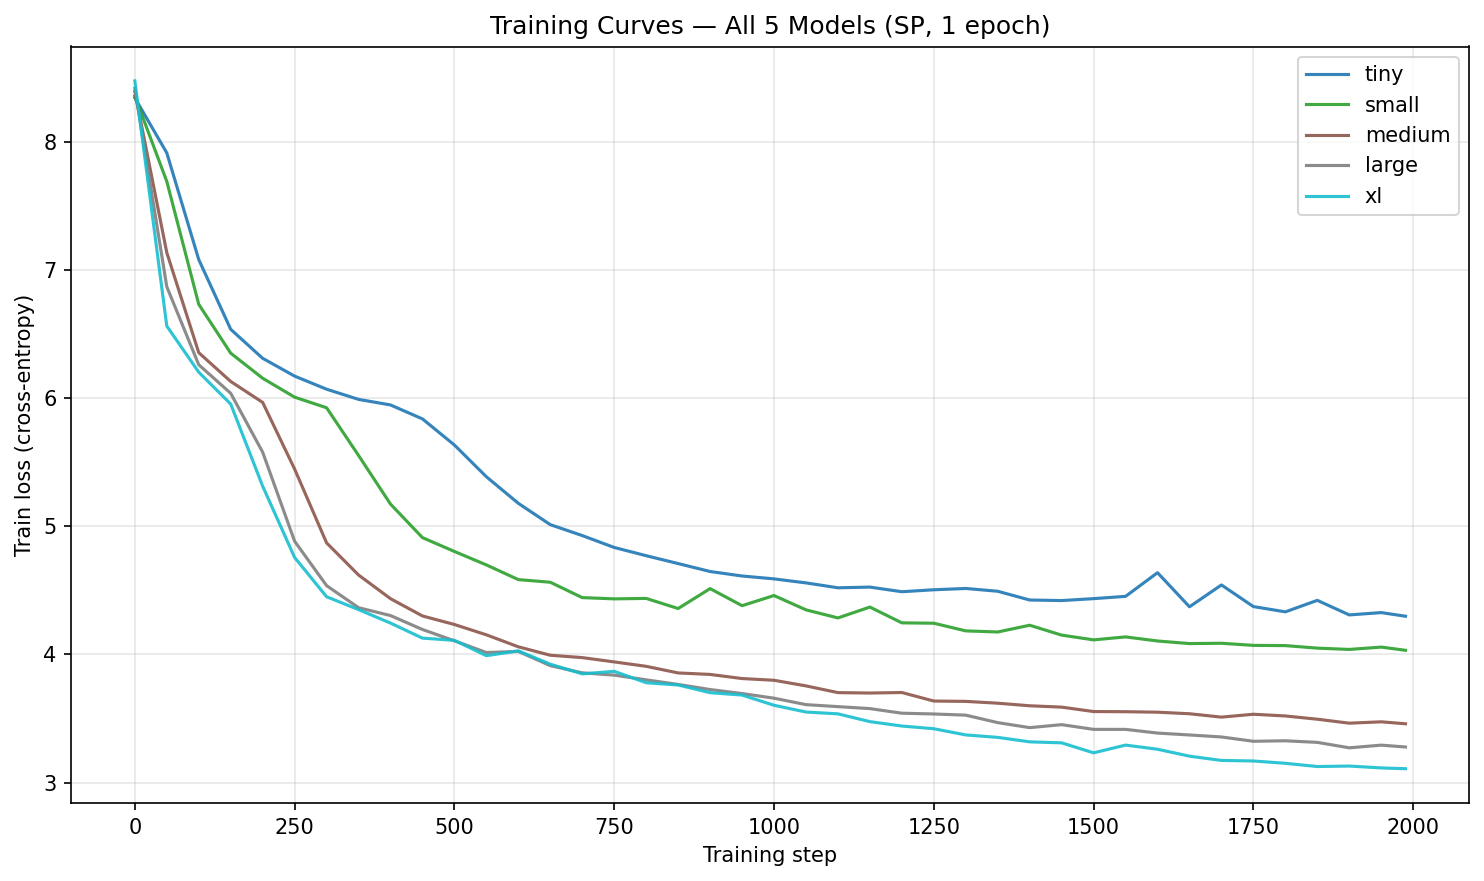


--- LR Sweep ---


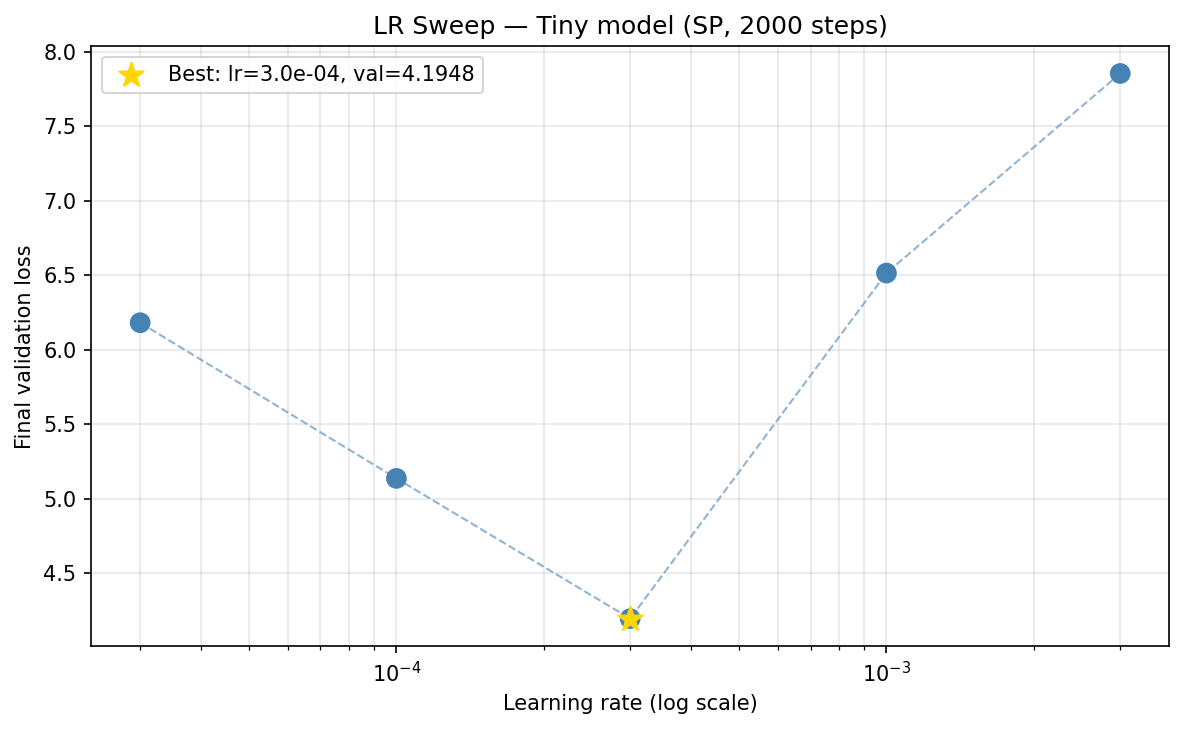

In [ ]:
from IPython.display import Image, display
import os

plots = [
    ('Scaling Law (SP)', 'outputs/plots/scaling_law_sp.png'),
    ('Training Curves',  'outputs/plots/training_curves.png'),
    ('LR Sweep',         'outputs/plots/lr_sweep_sp.png'),
]

for title, path in plots:
    if os.path.exists(path):
        print(f'\n--- {title} ---')
        display(Image(path))
    else:
        print(f'Missing: {path}')

---
## Cell 15: Scaling Law Summary

In [ ]:
import json, os

fit_path = 'outputs/logs/scaling_fit_sp.json'
if os.path.exists(fit_path):
    with open(fit_path) as f:
        fit = json.load(f)

    print('='*60)
    print('SCALING LAW FIT (Standard Parameterization)')
    print('='*60)
    print(f"  L = {fit['a']:.4f} * N^(-{fit['alpha']:.4f}) + {fit['c']:.4f}")
    print(f"  alpha   = {fit['alpha']:.4f}  (Kaplan NL: 0.076)")
    print(f"  R²      = {fit['r_squared']:.4f}")

    ex = fit.get('extrapolation_10x', {})
    if ex:
        print(f"\nExtrapolation (10× XL ≈ {ex['N']/1e6:.0f}M params):")
        print(f"  Predicted L = {ex['L_pred']:.4f}")
        print(f"  95% CI:       [{ex['L_lower']:.4f}, {ex['L_upper']:.4f}]")
else:
    print('scaling_fit_sp.json not found — run Cell 13 first.')

SCALING LAW FIT (Standard Parameterization)
  L = 15.7880 * N^(-0.1259) + 1.4966
  alpha   = 0.1259  (Kaplan NL: 0.076)
  R²      = 0.9842

Extrapolation (10× XL ≈ 851M params):
  Predicted L = 2.6824
  95% CI:       [2.1544, 3.2104]


---
## Done!

Phase 2 outputs saved to Drive:
| File | Purpose |
|------|---------|
| `outputs/checkpoints/<model>/best.pt` | Best checkpoint per model |
| `outputs/logs/training_<model>.csv` | Step-level training logs |
| `outputs/logs/result_<model>.json` | Final result per model |
| `outputs/logs/lr_sweep_sp.json` | LR sweep results |
| `outputs/logs/scaling_fit_sp.json` | Fitted power law parameters |
| `outputs/plots/scaling_law_sp.png` | Main scaling plot |
| `outputs/plots/training_curves.png` | Training curves all models |
| `outputs/plots/lr_sweep_sp.png` | LR sweep U-curve |

**Next:** Phase 3 — µP parameterization (`03_mup_study.ipynb`)